In [1]:
# General purpose
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Signal processing
from scipy.io import loadmat 
from scipy.ndimage import convolve1d
from scipy.signal import butter
from scipy.signal import sosfiltfilt
from scipy.signal import welch

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
# Hyperparameter tuning
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
# Feature selection
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest
# Dimensionality reduction
from sklearn.decomposition import PCA

RANDOM_STATE = 1
np.random.seed(RANDOM_STATE)

sns.set()


In [2]:
data = loadmat("S1_E1_A1.mat")
print("Dataset variables:")
print([key for key in data.keys() if not key.startswith("__")])

emg = data["emg"]
glove = data['glove']
print("EMG data dimension: {}".format(emg.shape))
print("EMG data type: {}".format(type(emg)))
print("Glove data dimension: {}".format(glove.shape))

stimulus = data['stimulus']
repetition = data['repetition']

N_STIMULI = len(np.unique(stimulus)) - 1 # -1 because 0 is the resting condition
N_REPETITIONS = len(np.unique(repetition)) - 1 # -1 because 0 is not a repetition

n_samples, n_channels = emg.shape

# time alignment
assert emg.shape[0] == glove.shape[0] == stimulus.shape[0]



FileNotFoundError: [Errno 2] No such file or directory: 'S1_E1_A1.mat'

In [101]:
fs = 2000 
t = np.arange(n_samples) / fs
print(f"Approx recording duration: {t[-1]:.1f} s")

Approx recording duration: 1146.3 s


Text(0.5, 1.02, 'Raw EMG, 5 s window')

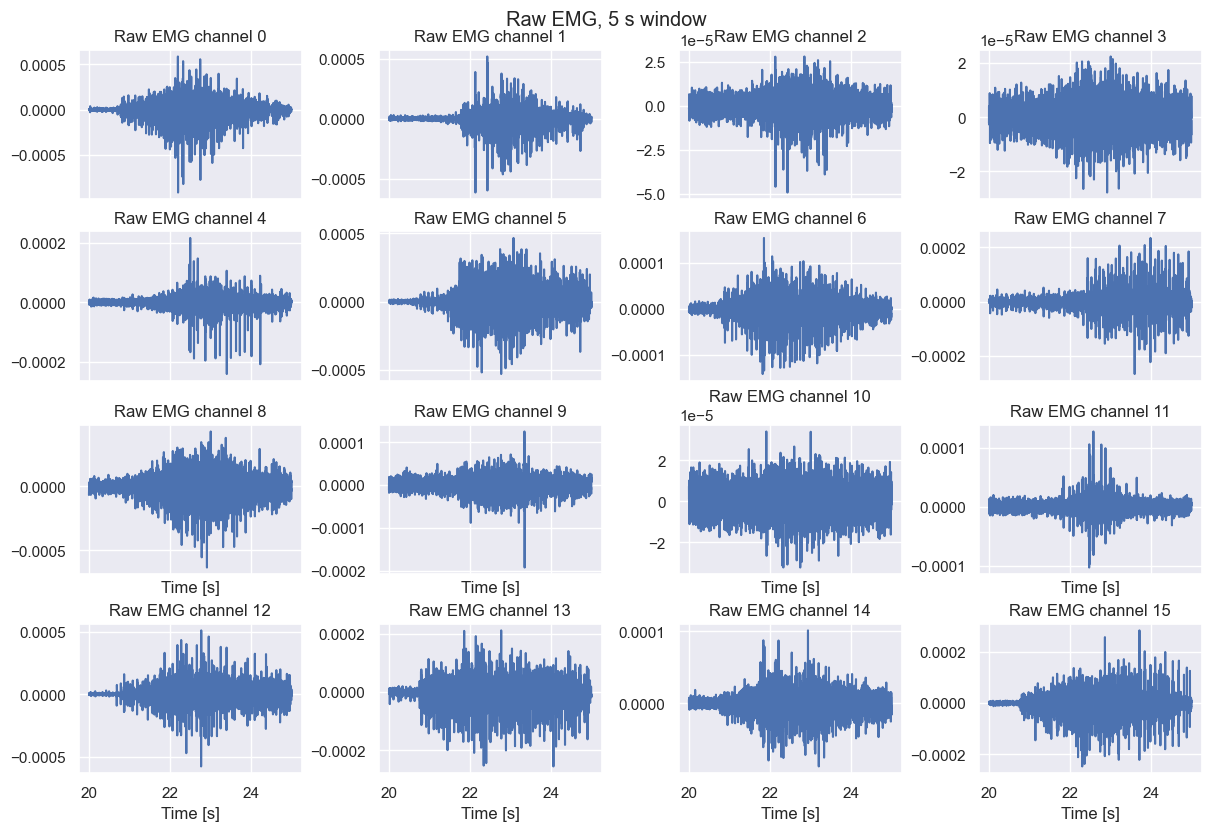

In [102]:
# pick a 5 s window somewhere in the middle
window_duration = 5  # seconds
start_time = 20      # seconds (you can change this)
start_idx = int(start_time * fs)
end_idx   = int((start_time + window_duration) * fs)
end_idx   = min(end_idx, n_samples)

segment_t   = t[start_idx:end_idx]
segment_emg = emg[start_idx:end_idx, :]

fig, ax = plt.subplots(4, 4, sharex=True, figsize=(12, 8), constrained_layout=True)
ax = ax.ravel()

for ch in range(n_channels):
    ax[ch].plot(segment_t, segment_emg[:, ch])
    ax[ch].set_title(f"Raw EMG channel {ch}")
    if ch >= 8:
        ax[ch].set_xlabel("Time [s]")

fig.suptitle("Raw EMG, 5 s window", y=1.02)


Text(0.5, 1.02, 'Glove signals, same 5 s window')

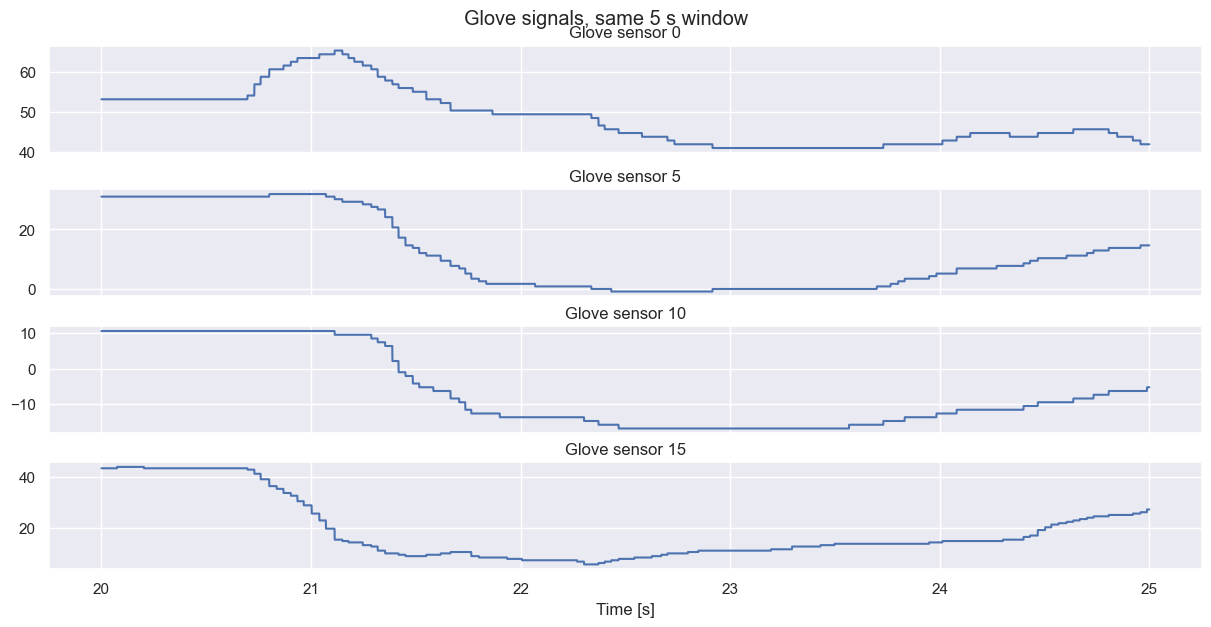

In [103]:
segment_glove = glove[start_idx:end_idx, :]

fig, ax = plt.subplots(4, 1, sharex=True, figsize=(12, 6), constrained_layout=True)

for i, gch in enumerate([0, 5, 10, 15]):
    ax[i].plot(segment_t, segment_glove[:, gch])
    ax[i].set_title(f"Glove sensor {gch}")
ax[-1].set_xlabel("Time [s]")

fig.suptitle("Glove signals, same 5 s window", y=1.02)

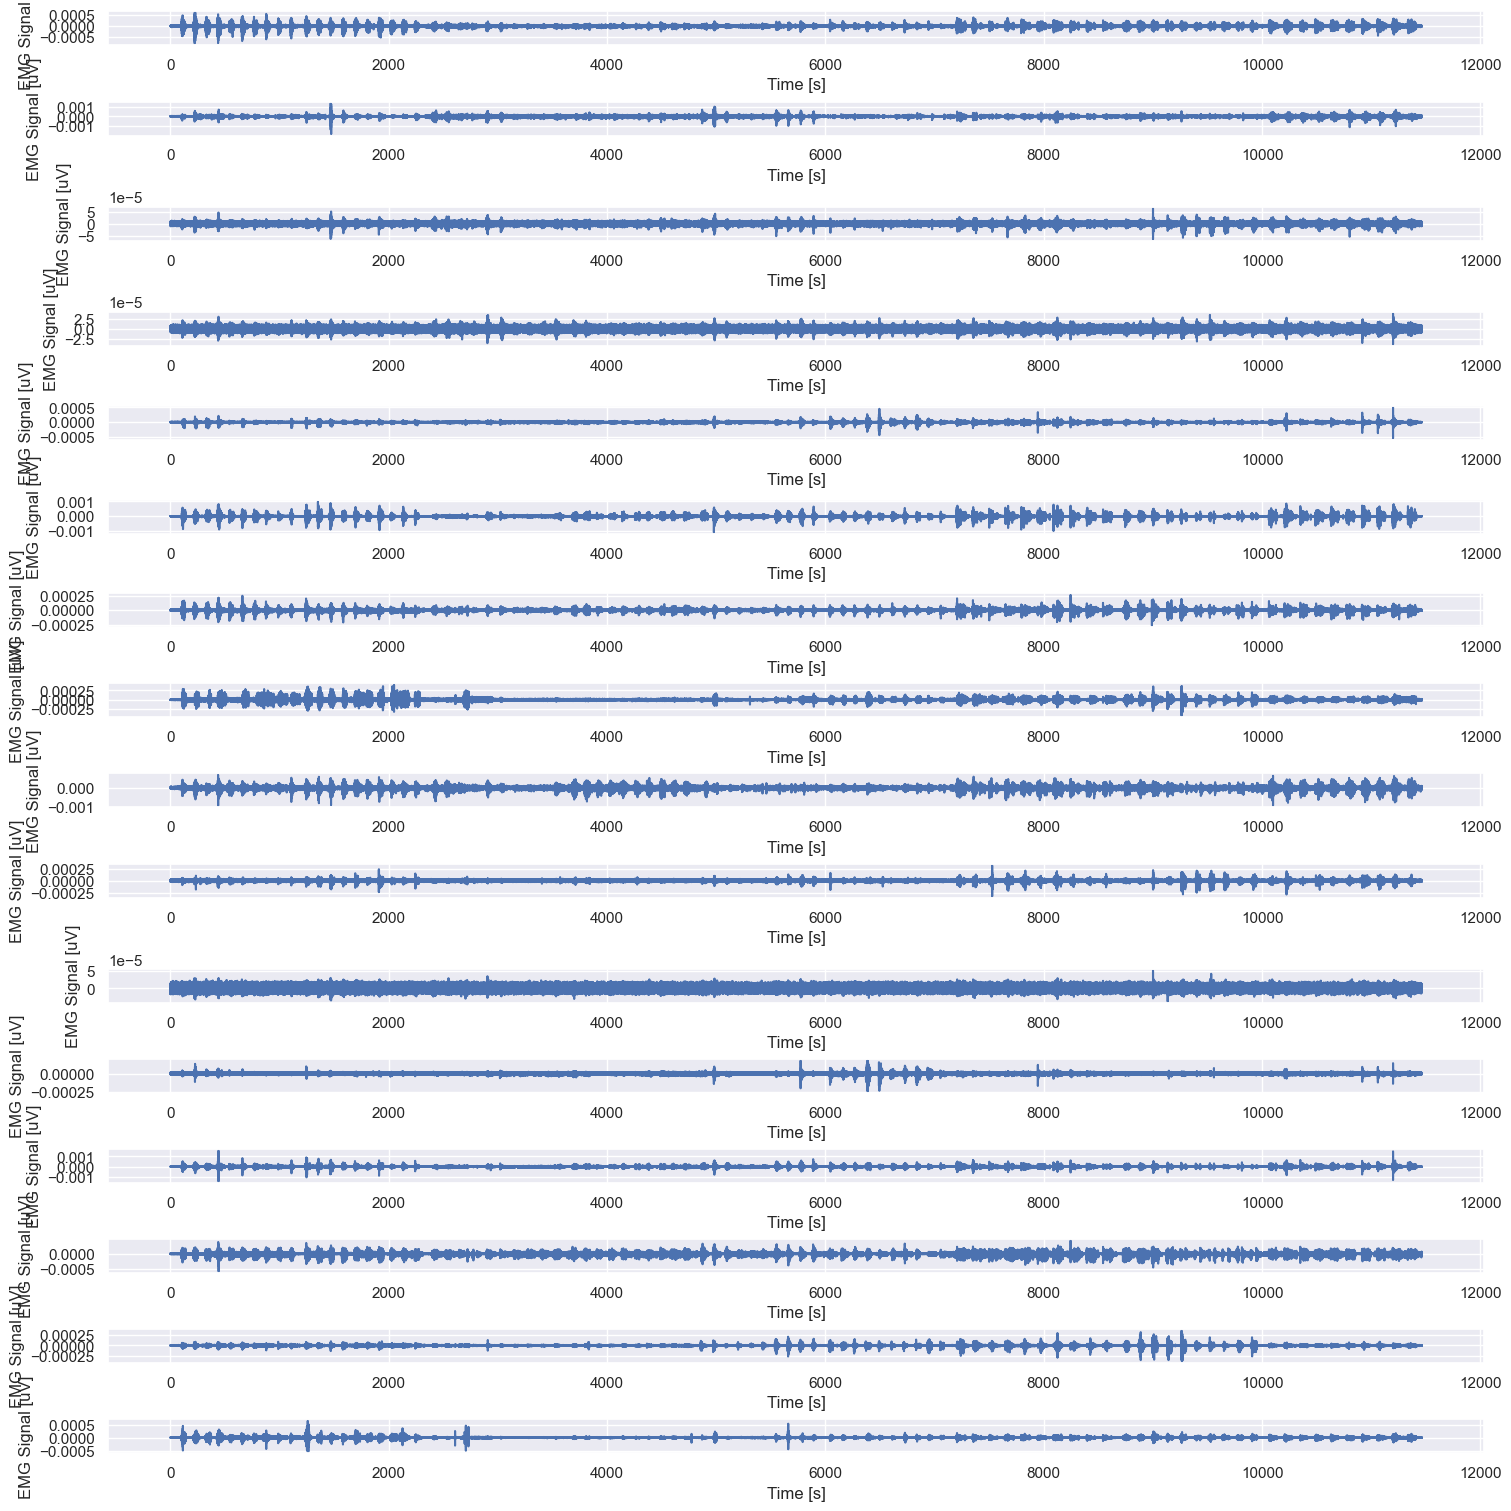

In [68]:
# preprocesssing
# apply bandpass filter
time_steps = np.arange(0,emg.shape[0]/fs, 1/fs)
bandpass_cutoff_frequencies_Hz = (5, 99) 
sos = butter(N=4, Wn=bandpass_cutoff_frequencies_Hz, fs=fs, btype="bandpass", output="sos") 
emg_filtered = sosfiltfilt(sos, emg.T).T 


powergrid_noise_frequencies_Hz = [harmonic_idx*50 for harmonic_idx in range(1,2)] # removing 50Hz noise and its harmonics

for noise_frequency in powergrid_noise_frequencies_Hz:
    sos = butter(N=4, Wn=(noise_frequency - 2, noise_frequency + 2), fs=fs, btype="bandstop", output="sos")
    emg_filtered = sosfiltfilt(sos, emg_filtered.T).T

fig, ax = plt.subplots(n_channels, 1, constrained_layout=True, figsize=(15, 15))
for i in range(n_channels):
    ax[i].plot(time_steps, emg_filtered[:, i])
    ax[i].set_xlabel("Time [s]")
    ax[i].set_ylabel("EMG Signal [uV]")

Text(0.5, 1.0, 'Power Spectral Density plot in Log scale')

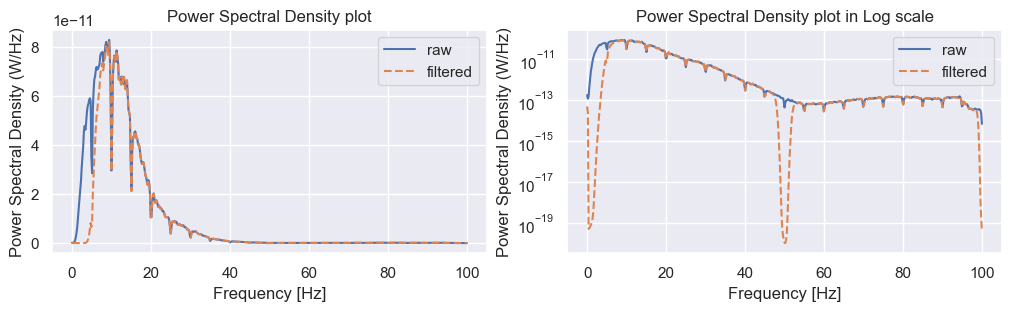

In [69]:
#Use Welch's method for power spectral density estimation, it reduces the variance of the estimate.
freqs_pre, Pxx_pre = welch(emg[:, 0], fs=fs, nperseg=1064)
freqs_post, Pxx_post = welch(emg_filtered[:, 0],fs = fs,  nperseg=1064)

fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(10, 3))
ax[0].plot(freqs_pre, Pxx_pre, label="raw")
ax[0].plot(freqs_post, Pxx_post, linestyle="--", label="filtered")
ax[0].legend()
ax[0].set_xlabel("Frequency [Hz]")
ax[0].set_ylabel("Power Spectral Density (W/Hz)")
ax[0].set_title("Power Spectral Density plot")

ax[1].semilogy(freqs_pre, Pxx_pre, label="raw")
ax[1].semilogy(freqs_post, Pxx_post, linestyle="--", label="filtered")
ax[1].legend()
ax[1].set_xlabel("Frequency [Hz]")
ax[1].set_ylabel("Power Spectral Density (W/Hz)")
ax[1].set_title("Power Spectral Density plot in Log scale")

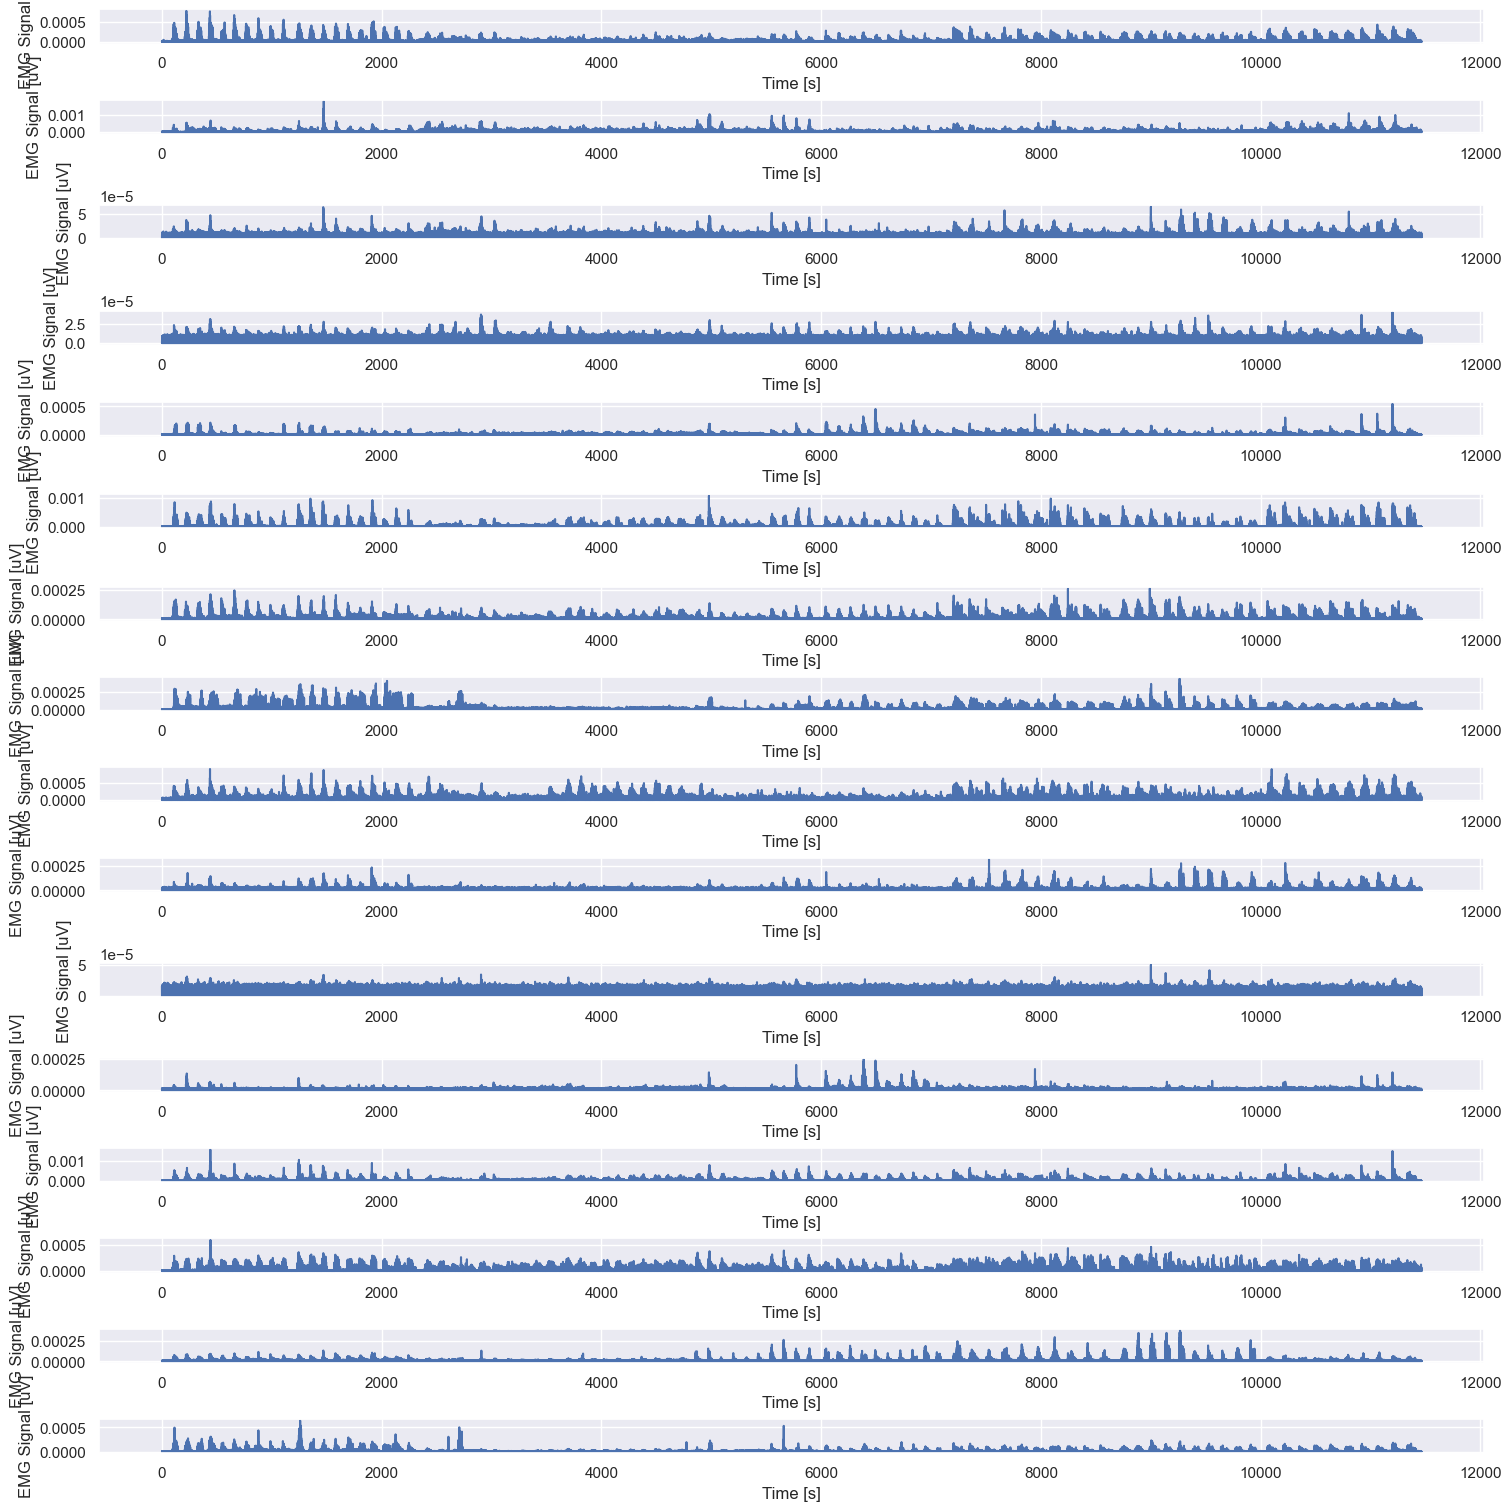

In [70]:
# Rectify signals
emg_rectified = np.abs(emg_filtered) # Rectify the signal

fig, ax = plt.subplots(n_channels, 1, constrained_layout=True, figsize=(15, 15))
for channel_idx in range(n_channels):
    ax[channel_idx].plot(time_steps, emg_rectified[:, channel_idx])
    ax[channel_idx].set_xlabel("Time [s]")
    ax[channel_idx].set_ylabel("EMG Signal [uV]")

In [71]:
# -1 because 0 is the resting condition
n_stimuli = len(np.unique(stimulus)) - 1 
# -1 because 0 is not a repetition
n_repetitions = len(np.unique(repetition)) - 1 
n_channels = emg_rectified.shape[1]

print(f'How many types of movement are there? {n_stimuli}') 
print(f'How many repetitions are there? {n_repetitions}') 

How many types of movement are there? 9
How many repetitions are there? 10


In [72]:
number_of_samples_per_trial = np.zeros((n_stimuli, n_repetitions))

for stimuli_idx in range(n_stimuli):
    for repetition_idx in range(n_repetitions):
        
        idx = np.logical_and(stimulus == stimuli_idx+1, repetition == repetition_idx+1)
        number_of_samples_per_trial[stimuli_idx, repetition_idx] = np.sum(idx.astype(int))

number_of_samples_per_trial

array([[14407., 13924., 13844., 13758., 13869., 13962., 13793., 13915.,
        13812., 13877.],
       [13970., 14039., 14110., 13883., 14720., 14136., 14080., 14131.,
        14215., 14003.],
       [16946., 16678., 16751., 17223., 16867., 17198., 16800., 16574.,
        16615., 17256.],
       [14582., 14591., 14637., 14734., 14672., 15001., 15210., 15082.,
        14550., 14651.],
       [15017., 14574., 14842., 14404., 15060., 14642., 14611., 14624.,
        14451., 14976.],
       [14907., 14588., 14639., 14754., 14912., 14791., 14750., 14638.,
        14618., 14656.],
       [21869., 21771., 21774., 21856., 21902., 21671., 21864., 22289.,
        22001., 21902.],
       [18655., 18580., 18038., 18660., 18109., 18162., 17976., 17999.,
        17895., 17795.],
       [20265., 20159., 20844., 20292., 20276., 20363., 20571., 20251.,
        20199., 20523.]])

In [73]:
#defining the length of the moving average window
mov_mean_length = 25
mov_mean_weights = np.ones(mov_mean_length) / mov_mean_length

#initializing the data structure
emg_windows = [[None for repetition_idx in range(n_repetitions)] for stimuli_idx in range(n_stimuli)]
emg_envelopes = [[None for repetition_idx in range(n_repetitions)] for stimuli_idx in range(n_stimuli)]

for stimuli_idx in range(n_stimuli):
    for repetition_idx in range(n_repetitions):
        idx = np.logical_and(stimulus == stimuli_idx + 1, repetition == repetition_idx + 1).flatten()
        emg_windows[stimuli_idx][repetition_idx] = emg_rectified[idx, :]
        emg_envelopes[stimuli_idx][repetition_idx] = convolve1d(emg_windows[stimuli_idx][repetition_idx], mov_mean_weights, axis=0) 

16


Text(0.5, 0.98, 'Envelopes of the EMG signal')

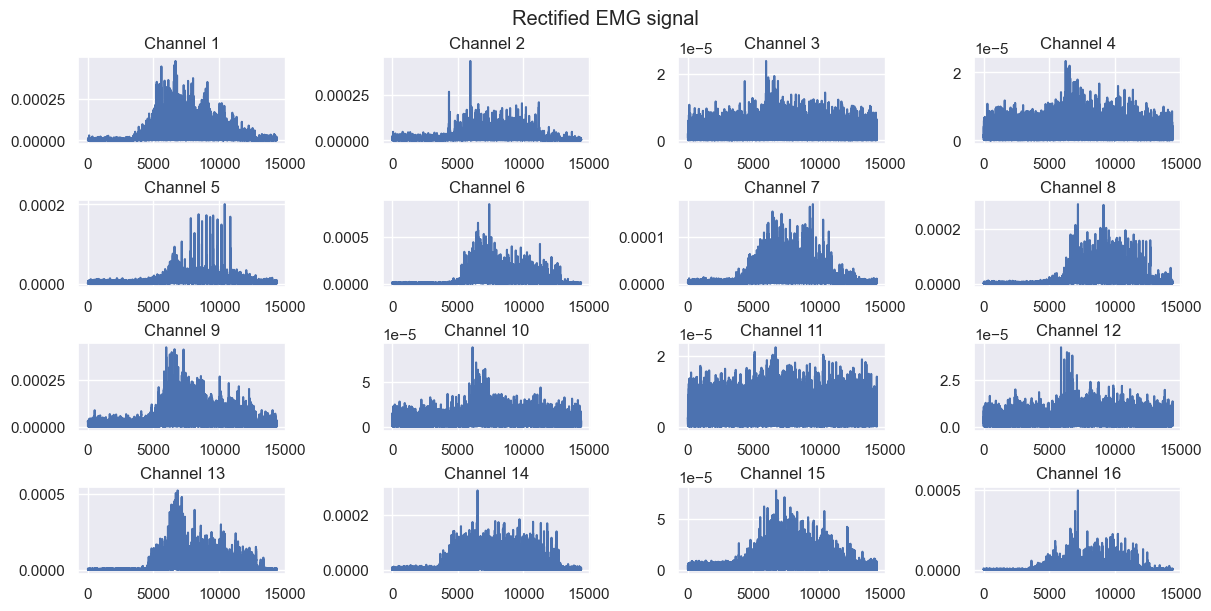

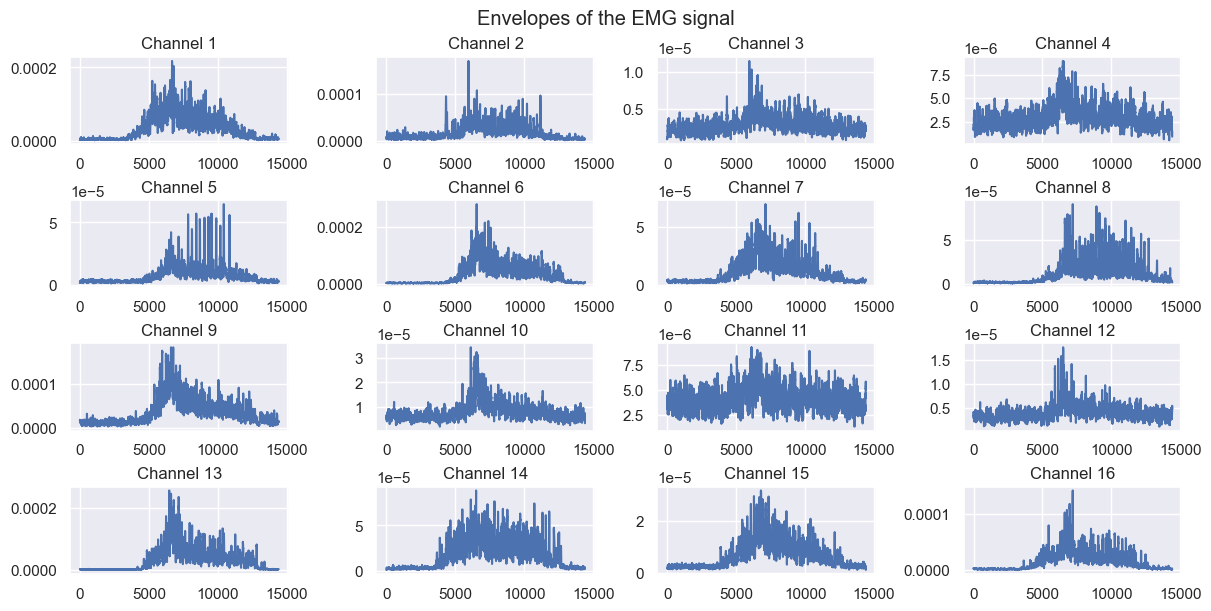

In [74]:
fig, ax = plt.subplots(4, 4, figsize=(12, 6), constrained_layout=True)
ax = ax.ravel()

#10 EMG channels
number_of_emg_channels = emg_rectified.shape[-1]
print(number_of_emg_channels)
# plot Rectified EMG signal
for channel_idx in range(number_of_emg_channels): 
    ax[channel_idx].plot(emg_windows[0][0][:, channel_idx])
    ax[channel_idx].set_title(f"Channel {channel_idx+1}")
plt.suptitle("Rectified EMG signal")

# plot Envelopes of the EMG signal
fig, ax = plt.subplots(4, 4, figsize=(12, 6), constrained_layout=True)
ax = ax.ravel()
for channel_idx in range(number_of_emg_channels): 
    ax[channel_idx].plot(emg_envelopes[0][0][:, channel_idx])
    ax[channel_idx].set_title(f"Channel {channel_idx+1}")
plt.suptitle("Envelopes of the EMG signal")

Text(0.5, 0.98, 'Envelopes of the EMG signal')

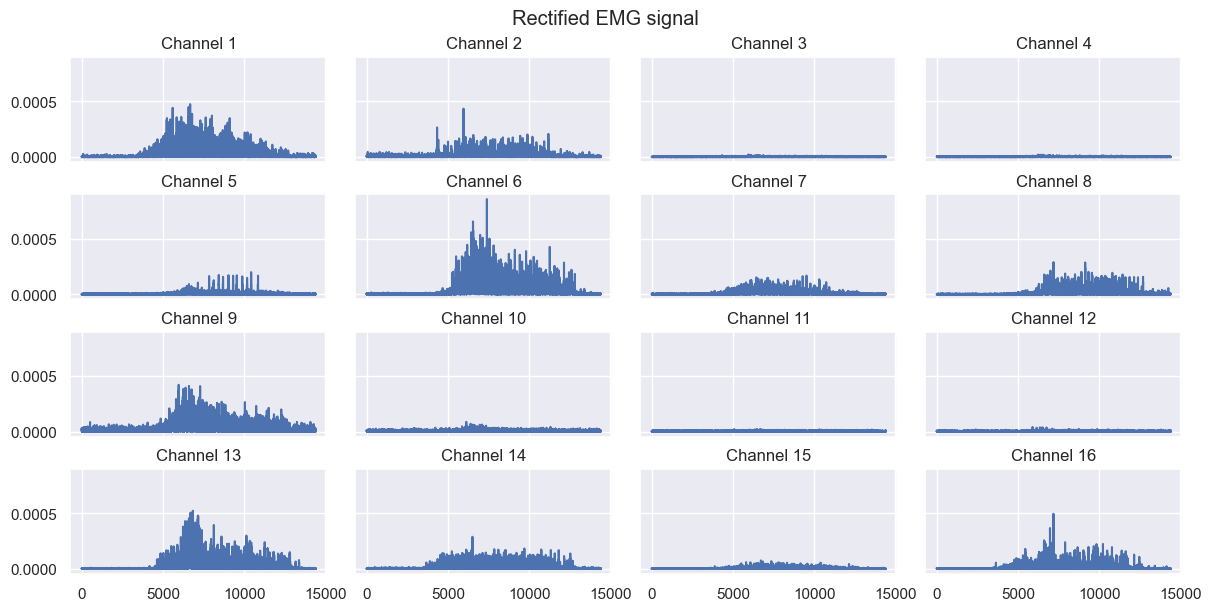

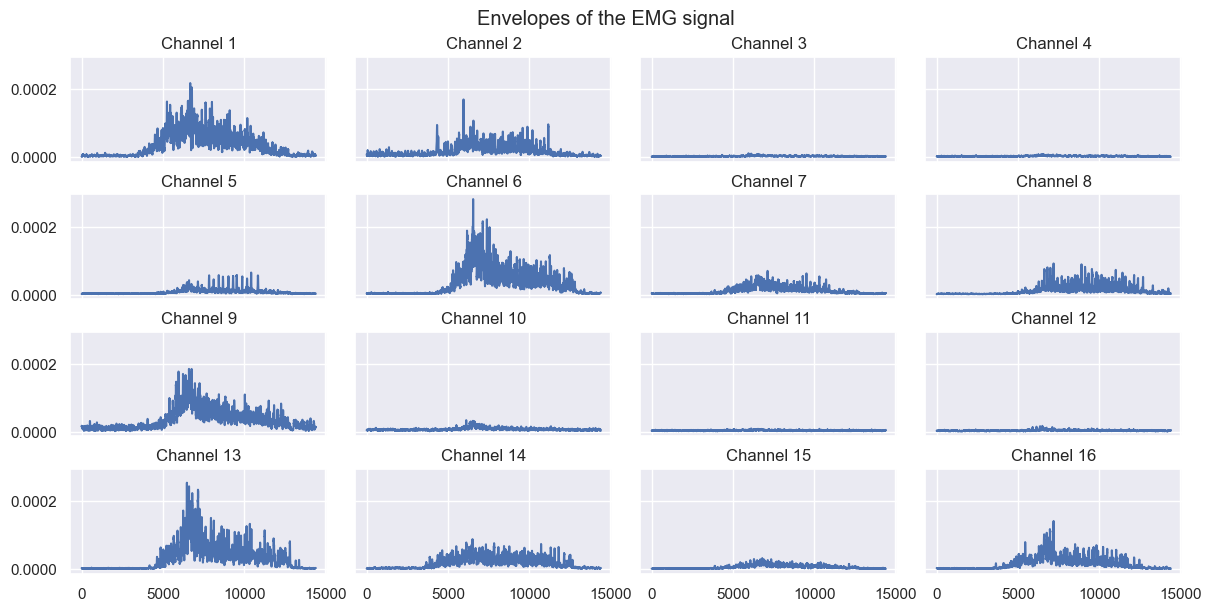

In [75]:
# Now we plot all the channels on the same y-scale
fig, ax = plt.subplots(4, 4, figsize=(12, 6), constrained_layout=True, sharex=True, sharey=True)
ax = ax.ravel()

number_of_emg_channels = emg_rectified.shape[-1]
# plot Rectified EMG signal
for channel_idx in range(number_of_emg_channels): 
    ax[channel_idx].plot(emg_windows[0][0][:, channel_idx])
    ax[channel_idx].set_title(f"Channel {channel_idx+1}")
plt.suptitle("Rectified EMG signal")

# plot Envelopes of the EMG signal
fig, ax = plt.subplots(4, 4, figsize=(12, 6), constrained_layout=True, sharex=True, sharey=True)
ax = ax.ravel()
for channel_idx in range(number_of_emg_channels): 
    ax[channel_idx].plot(emg_envelopes[0][0][:, channel_idx])
    ax[channel_idx].set_title(f"Channel {channel_idx+1}")
plt.suptitle("Envelopes of the EMG signal")

In [ ]:
# delete channels that are not helpful

In [76]:
emg_average_activations = np.zeros((n_channels, n_stimuli, n_repetitions))
for stimuli_idx in range(n_stimuli):
    for repetition_idx in range(n_repetitions):
        #mean across time for each channel
        emg_average_activations[:, stimuli_idx, repetition_idx] = np.mean(emg_envelopes[stimuli_idx][repetition_idx], axis=0) 

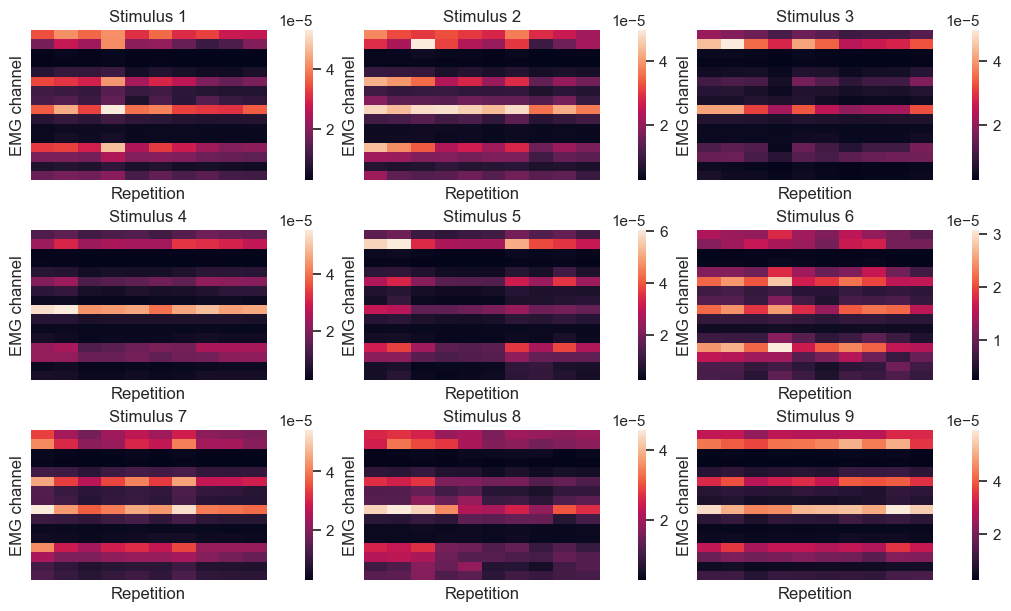

In [77]:
fig, ax = plt.subplots(3, 3, figsize=(10, 6), constrained_layout=True, sharex=True, sharey=True)
ax = ax.ravel()

for stimuli_idx in range(n_stimuli):
    sns.heatmap(np.squeeze(emg_average_activations[:, stimuli_idx, :]), ax=ax[stimuli_idx] ,xticklabels=False, yticklabels=False, cbar = True)
    ax[stimuli_idx].title.set_text("Stimulus " + str(stimuli_idx + 1))
    ax[stimuli_idx].set_xlabel("Repetition")
    ax[stimuli_idx].set_ylabel("EMG channel")

# Classification

In [ ]:
# Define the features 

# Mean absolute value (MAV)
mav = lambda x: np.mean(np.abs(x), axis=0)
# Standard Deviation (STD)
std = lambda x: np.std(x, axis=0)
# Maximum absolute Value (MaxAV)
maxav = lambda x: np.max(np.abs(x), axis=0)
# Root mean square (RMS)
rms = lambda x: np.sqrt(np.mean(x**2, axis=0))
# Waveform length (WL)
wl = lambda x: np.sum(np.abs(np.diff(x, axis=0)), axis=0)
# Slope sign changes (SSC)
ssc = lambda x: np.sum((np.diff(x, axis=0)[:-1, :] * np.diff(x, axis=0)[1:, :]) < 0, axis=0)
# Teager-Kaiser Energy (TKE)
tke = lambda x: np.sum(x[1:-1, :]**2 - x[:-2, :] * x[2:, :], axis=0)
# sparsity (SPAR)
spar = lambda x: np.sum(np.abs(x), axis=0)**2 / (x.shape[0] * np.sum(x**2, axis=0)) 
# irregularity (IRR)
irr = lambda x: np.sum(np.abs(np.diff(x, axis=0)), axis=0) / (np.sum(np.abs(x), axis=0) + 1e-6) 


dataset dimension: (90, 112)
labels dimension: (90,)


In [28]:
# perform cross-validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(clf, X_train_z, y_train, cv=5)
print(f"Accuracy scores of all models: {scores}")
print(f"Mean accuracy across all models: {np.mean(scores)}")

Accuracy scores of all models: [0.92307692 0.76923077 0.76923077 0.66666667 0.66666667]
Mean accuracy across all models: 0.7589743589743589


In [29]:
# use cross validation to find the best hyperparameters for SVC

from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_neighbors": [1,3,5,7,9],
    "weights": ['uniform', 'distance'],
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid)
grid.fit(X_train_z, y_train)

print(f"Best estimator: {grid.best_estimator_}")
print(f"Best hyperparameters: {grid.best_params_}")

y_pred = grid.predict(X_test_z)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy score of best model: {accuracy}")

Best estimator: KNeighborsClassifier(n_neighbors=1)
Best hyperparameters: {'n_neighbors': 1, 'weights': 'uniform'}
Accuracy score of best model: 0.8518518518518519


Estimated mutual information between each feature and the target:
 [0.85014804 0.55214577 0.35406521 0.18271489 0.42458238 0.63043455
 0.44576495 0.69410278 0.66554968 0.64503013 0.33820174 0.51876625
 0.4481868  0.33039135 0.78838031 0.90868341 0.84508734 0.39079693
 0.37451818 0.13306657 0.42826455 0.57004181 0.42766083 0.83108005
 0.58603171 0.63931884 0.30279653 0.44086661 0.32433463 0.39352148
 0.7751228  0.92736971 0.76337152 0.13567166 0.369427   0.04134803
 0.37954009 0.6000555  0.4814107  0.82706956 0.6423358  0.42356703
 0.04702044 0.23705732 0.18454181 0.29999907 0.63126169 0.7851144
 0.8282996  0.50795742 0.60223341 0.63146585 0.47947167 0.63957471
 0.57397682 0.76229936 0.7460873  0.76402614 1.09033684 0.73464238
 0.40391775 0.68860378 0.80226998 0.82100172 0.7234689  0.44184337
 0.42401855 0.         0.44354014 0.49199102 0.34130912 1.02075369
 0.1019503  0.52816528 0.1548951  0.29484417 0.36720608 0.27025813
 0.80281495 0.69369379 1.08523775 0.64857664 0.35571784 0.23705

Text(0.5, 20.049999999999997, 'Predicted label')

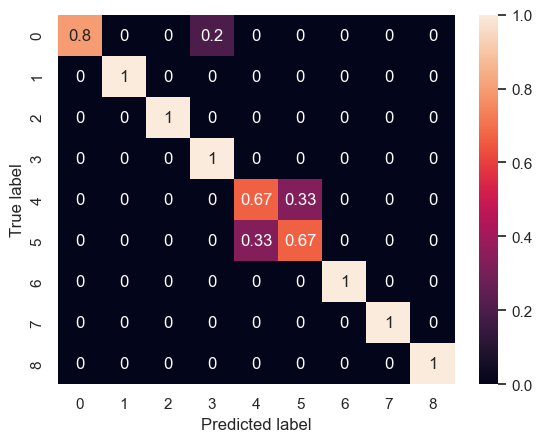

In [30]:
# Import necessary functions for feature selection
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest

# Calculate mutual information between each feature and the target variable.
# Mutual information is a measure of the dependency between variables.
# A higher value indicates a stronger relationship.
mutual_info = mutual_info_classif(X_train_z, y_train)
print(f"Estimated mutual information between each feature and the target:\n {mutual_info}\n")

# Select the top 10 features based on mutual information scores.
# Note: You can change 'k' to 30 if you are working with more features.
k_best = SelectKBest(mutual_info_classif, k=10)
k_best.fit(X_train_z, y_train)

# Transform the training and test datasets to only include the selected features.
X_train_best = k_best.transform(X_train_z)
X_test_best = k_best.transform(X_test_z)

clf = KNeighborsClassifier(**grid.best_params_) # use the best parameters found before, You can also perform another round of grid search with the new features
clf.fit(X_train_best, y_train)

# Predict the labels for the test set using the trained model.
y_pred = clf.predict(X_test_best)

# Calculate the accuracy of the model with the selected features.
# Accuracy is the ratio of correctly predicted instances to the total instances.
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy score of a model with k best features: {accuracy}")

# Create a confusion matrix to visualize the performance of the classification model.
# The confusion matrix shows the true vs predicted labels.
confmat = confusion_matrix(y_test, y_pred, normalize="true")

# Plot the confusion matrix using a heatmap for better visualization.
fig, ax = plt.subplots()
sns.heatmap(confmat, annot=True, ax=ax)
ax.set_ylabel("True label")
ax.set_xlabel("Predicted label")

# Lab 12

Glove data dimension: (2292526, 5)
Glove data type: <class 'numpy.ndarray'>
EMG data dimension: (2292526, 16)
EMG data type: <class 'numpy.ndarray'>
Glove data dimension: (2292526, 18)
How many types of movement are there? 9
How many repetitions are there? 10
Approx recording duration: 11462.6 s


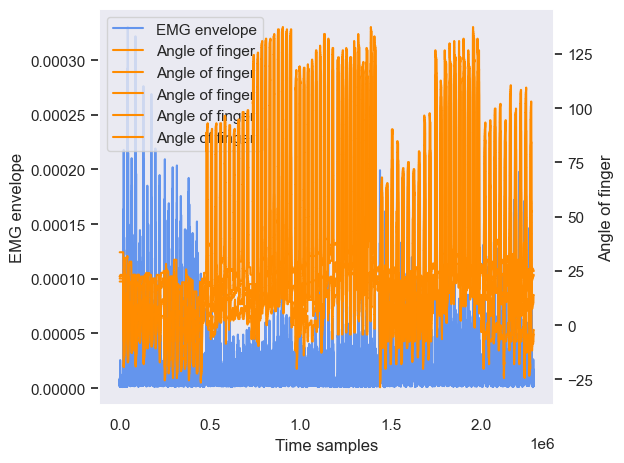

In [125]:
joint_indices = [2, 5, 7, 10, 13]
glove_data_index = data["glove"][:, joint_indices]
print("Glove data dimension:", glove_data_index.shape)
print("Glove data type:", type(glove_data_index))



emg = data["emg"]
glove = data['glove']
print("EMG data dimension: {}".format(emg.shape))
print("EMG data type: {}".format(type(emg)))
print("Glove data dimension: {}".format(glove.shape))

stimulus = data['stimulus']
repetition = data['repetition']

#N_STIMULI = len(np.unique(stimulus)) - 1 # -1 because 0 is the resting condition
#N_REPETITIONS = len(np.unique(repetitio
print(f'How many types of movement are there? {n_stimuli}') 
print(f'How many repetitions are there? {n_repetitions}') 

# time alignment
assert emg.shape[0] == glove.shape[0] == stimulus.shape[0]

fs = 200 
t = np.arange(n_samples) / fs
print(f"Approx recording duration: {t[-1]:.1f} s")

# preprocesssing
# apply bandpass filter
time_steps = np.arange(0,emg.shape[0]/fs, 1/fs)
bandpass_cutoff_frequencies_Hz = (5, 99) 
sos = butter(N=4, Wn=bandpass_cutoff_frequencies_Hz, fs=fs, btype="bandpass", output="sos") 
emg_filtered = sosfiltfilt(sos, emg.T).T 


powergrid_noise_frequencies_Hz = [harmonic_idx*50 for harmonic_idx in range(1,2)] # removing 50Hz noise and its harmonics

for noise_frequency in powergrid_noise_frequencies_Hz:
    sos = butter(N=4, Wn=(noise_frequency - 2, noise_frequency + 2), fs=fs, btype="bandstop", output="sos")
    emg_filtered = sosfiltfilt(sos, emg_filtered.T).T

# -1 because 0 is the resting condition
n_stimuli = len(np.unique(stimulus)) - 1 
# -1 because 0 is not a repetition
n_repetitions = len(np.unique(repetition)) - 1 
n_channels = emg_rectified.shape[1]


n_samples, n_channels = emg.shape

#Use Welch's method for power spectral density estimation, it reduces the variance of the estimate.
freqs_pre, Pxx_pre = welch(emg[:, 0], fs=fs, nperseg=1064)
freqs_post, Pxx_post = welch(emg_filtered[:, 0],fs = fs,  nperseg=1064)

# Rectify signals
emg_rectified = np.abs(emg_filtered) # Rectify the signal
# -1 because 0 is the resting condition
n_stimuli = len(np.unique(stimulus)) - 1 
# -1 because 0 is not a repetition
n_repetitions = len(np.unique(repetition)) - 1 
n_samples, n_channels = emg_rectified.shape


#defining the length of the moving average window
#mov_mean_length = 25
#mov_mean_weights = np.ones(mov_mean_length) / mov_mean_length

#initializing the data structure
#emg_windows = [[None for repetition_idx in range(n_repetitions)] for stimuli_idx in range(n_stimuli)]
#emg_envelopes = [[None for repetition_idx in range(n_repetitions)] for stimuli_idx in range(n_stimuli)]

#for stimuli_idx in range(n_stimuli):
#    for repetition_idx in range(n_repetitions):
#        idx = np.logical_and(stimulus == stimuli_idx + 1, repetition == repetition_idx + 1).flatten()
#        emg_windows[stimuli_idx][repetition_idx] = emg_rectified[idx, :]
#        emg_envelopes[stimuli_idx][repetition_idx] = convolve1d(emg_windows[stimuli_idx][repetition_idx], mov_mean_weights, axis=0) 
        




mov_mean_size = 25
mov_mean_weights = np.ones(mov_mean_size) / mov_mean_size
EMG_envelopes = convolve1d(emg_rectified, weights=mov_mean_weights, axis=0)

fig, ax = plt.subplots()
ax.plot(EMG_envelopes[:, 0],color = 'cornflowerblue', label="EMG envelope")
ax.set_ylabel("EMG envelope")
ax.set_xlabel("Time samples")
ax.grid(False)

finger_angle_ax = ax.twinx()
finger_angle_ax.plot(glove_data_index[:, :], color="darkorange", label="Angle of finger")
finger_angle_ax.set_ylabel("Angle of finger")
finger_angle_ax.grid(False)

# Get handles and labels for legend
emg_handles, emg_labels = ax.get_legend_handles_labels()
finger_angle_handles, finger_angle_labels = finger_angle_ax.get_legend_handles_labels()

# Combine handles and labels
combined_handles = emg_handles + finger_angle_handles
combined_labels = emg_labels + finger_angle_labels

# Create a single legend
ax.legend(combined_handles, combined_labels, loc='upper left')
plt.tight_layout()

In [126]:
from sklearn.model_selection import train_test_split

# Chronologically cut the whole dataset before creating overlapping windows
#EMG_train, EMG_test, Labels_train, Labels_test = train_test_split(emg, glove, test_size=0.2, shuffle=False)

TRAIN_PCT = .6
VAL_PCT = .2
TEST_PCT = .2
CV_K = round((TRAIN_PCT+VAL_PCT) / VAL_PCT)

assert TRAIN_PCT + VAL_PCT + TEST_PCT == 1.0
# Fixed train/val/test split
X_trainval, EMG_test, y_trainval, Labels_test = train_test_split(
    EMG_envelopes, glove, 
    test_size=TEST_PCT, 
    shuffle=False,
)

EMG_train, EMG_val, Labels_train, Labels_val = train_test_split(
    X_trainval, y_trainval,
    test_size=VAL_PCT / (TRAIN_PCT + VAL_PCT),
    shuffle=False,
)

In [127]:
print(f"EMG train data shape: {EMG_train.shape},    Train label shape: {Labels_train.shape}")
print(f"EMG test data shape: {EMG_test.shape},      Test label shape: {Labels_test.shape}")
print(f"EMG val data shape: {EMG_val.shape},        Val label shape: {Labels_val.shape}")

EMG train data shape: (1375515, 16),    Train label shape: (1375515, 18)
EMG test data shape: (458506, 16),      Test label shape: (458506, 18)
EMG val data shape: (458505, 16),        Val label shape: (458505, 18)


In [128]:
fs = 2000  # [Hz], from dataset description
emg_window_length_sec = 200e-3  # [s]
incremental_window_length_sec = 40e-3  # [s]

In [82]:
def extract_time_windows_regression(EMG: np.ndarray, Label: np.ndarray, fs: int, win_len: int, step: int):
# This function is used to cut the time windows from the raw EMG 
# It return a lists containing the EMG of each time window.
# It also returns the target corresponding to the time of the end of the window
    """
    This function is defined to perform an overlapping sliding window 
    :param EMG: Numpy array containing the data
    :param Label: Numpy array containing the targets
    :param fs: the sampling frequency of the signal
    :param win_len: The size of the windows (in seconds)
    :param step: The step size between windows (in seconds)

    :return: A Numpy array containing the windows
    :return: A Numpy array containing the targets aligned for each window
    :note: The lengths of both outputs are the same
    """
    
    n,m = EMG.shape
    win_len = int(win_len*fs)
    start_points = np.arange(0,n-win_len,int(step*fs))
    end_points = start_points + win_len

    EMG_windows = np.zeros((len(start_points),win_len,m))
    Labels_window = np.zeros((len(start_points),win_len,Label.shape[1]))
    for i in range(len(start_points)):
        EMG_windows[i,:,:] = EMG[start_points[i]:end_points[i],:]
        Labels_window[i,:,:] = Label[start_points[i]:end_points[i],:]
    

    return EMG_windows, Labels_window

In [129]:
# extract over lapping time windows on train set and test set
EMG_train_windows, Labels_train_windows = extract_time_windows_regression(EMG_train, Labels_train, fs, emg_window_length_sec, incremental_window_length_sec)

EMG_test_windows, Labels_test_windows = extract_time_windows_regression(EMG_test, Labels_test, fs, emg_window_length_sec, incremental_window_length_sec)

EMG_val_windows, Labels_val_windows = extract_time_windows_regression(EMG_val, Labels_val, fs, emg_window_length_sec, incremental_window_length_sec)

print(f"EMG train windows shape: {EMG_train_windows.shape}, Train label windows shape: {Labels_train_windows.shape}")
print(f"EMG test windows shape: {EMG_test_windows.shape},   Test label windows shape: {Labels_test_windows.shape}")
print(f"EMG val windows shape: {EMG_val_windows.shape},     Val label windows shape: {Labels_val_windows.shape}")

EMG train windows shape: (17189, 400, 16), Train label windows shape: (17189, 400, 18)
EMG test windows shape: (5727, 400, 16),   Test label windows shape: (5727, 400, 18)
EMG val windows shape: (5727, 400, 16),     Val label windows shape: (5727, 400, 18)


In [ ]:
#def extract_features(EMG_windows: np.ndarray, Labels_windows: np.ndarray):
    """
    This function is defined to extract the mean and standard deviation of each window
    :param EMG_windows: A Numpy array containing the windows
    :return: A Numpy array containing the mean, the standard deviation and the maximum amplitude of each window and the mean of the labels window
    """
    # along axis 1, which is the time axis
    EMG_mean = np.mean(EMG_windows,axis=1)
    EMG_std = np.std(EMG_windows,axis=1)
    EMG_max_amplitude = np.max(EMG_windows, axis=1)
    Labels_mean = np.mean(Labels_windows,axis=1)
    
    # Concatenate the mean and std of each window
    EMG_extracted_features = np.concatenate((EMG_mean, EMG_std, EMG_max_amplitude), axis=1)
    return EMG_extracted_features, Labels_mean

In [84]:
from scipy.stats import mode

def extract_features(
    EMG_windows: np.ndarray,
    Labels_windows: np.ndarray,
    feature_fns
):
    """
    Extract EMG features from windowed EMG.

    Parameters
    ----------
    EMG_windows : ndarray
        Shape (n_windows, window_length, n_channels)
    Labels_windows : ndarray
        Shape (n_windows, window_length)
    feature_fns : list
        List of feature functions f(x) -> (n_channels,)

    Returns
    -------
    X : ndarray
        Shape (n_windows, n_channels * n_features)
    y : ndarray
        Shape (n_windows,)
    """

    n_windows, _, n_channels = EMG_windows.shape
    n_features = len(feature_fns)

    X = np.zeros((n_windows, n_channels * n_features))

    for i in range(n_windows):
        feats = []
        for fn in feature_fns:
            feats.append(fn(EMG_windows[i]))  # (n_channels,)
        X[i, :] = np.concatenate(feats)

    # Label per window (majority vote – better than mean)
    y = mode(Labels_windows, axis=1, keepdims=False).mode

    return X, y

In [130]:
feature_fns = [mav, std, maxav, tke, spar, irr, wl]

EMG_train_extracted_features, Labels_train_mean = extract_features(EMG_train_windows,Labels_train_windows, feature_fns)
EMG_test_extracted_features, Labels_test_mean = extract_features(EMG_test_windows,Labels_test_windows, feature_fns)
EMG_val_extracted_features, Labels_val_mean = extract_features(EMG_val_windows,Labels_val_windows, feature_fns)
print("EMG train extracted features shape: {}, Finger labels feature shape:{}".format(EMG_train_extracted_features.shape, Labels_train_mean.shape))
print("EMG test extracted features shape: {}, Finger labels feature shape:{}".format(EMG_test_extracted_features.shape, Labels_test_mean.shape))
print("EMG val extracted features shape: {}, Finger labels feature shape:{}".format(EMG_val_extracted_features.shape, Labels_val_mean.shape))

EMG train extracted features shape: (17189, 112), Finger labels feature shape:(17189, 18)
EMG test extracted features shape: (5727, 112), Finger labels feature shape:(5727, 18)
EMG val extracted features shape: (5727, 112), Finger labels feature shape:(5727, 18)


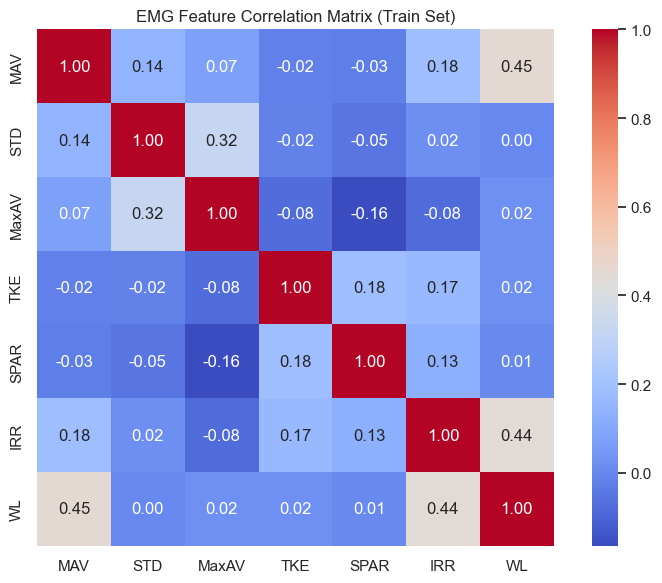

In [131]:
feature_names = ["MAV", "STD", "MaxAV", "TKE", "SPAR", "IRR", "WL"]
n_features = len(feature_names)

n_windows, total_dims = EMG_train_extracted_features.shape
n_channels = total_dims // n_features

# reshape: (windows, channels, features)
X_train_reshaped = EMG_train_extracted_features.reshape(n_windows, n_channels, n_features)

# average across channels
X_train_feat = X_train_reshaped.mean(axis=1)  # (n_windows, n_features)

# correlation
corr_matrix = np.corrcoef(X_train_feat, rowvar=False)


plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    xticklabels=feature_names,
    yticklabels=feature_names,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)
plt.title("EMG Feature Correlation Matrix (Train Set)")
plt.tight_layout()
plt.show()

In [132]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_z = scaler.fit_transform(EMG_train_extracted_features)
X_test_z = scaler.transform(EMG_test_extracted_features)
X_val_z = scaler.transform(EMG_val_extracted_features)

In [133]:
from sklearn.linear_model import LinearRegression

#Fit and predict using the linear regressor
linear_regressor = LinearRegression() 
linear_regressor.fit(X_train_z, Labels_train_mean)
y_pred_linear = linear_regressor.predict(X_test_z)

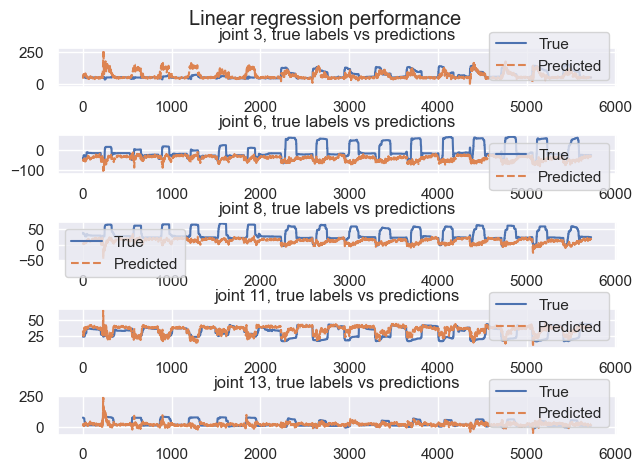

In [134]:
# Check prediction accuracy in finger angle [2, 5, 7, 10, 13]
plt.close("all")
fig, ax = plt.subplots(5, 1)
fig.tight_layout()
fig.subplots_adjust(top= 0.9)
fig.suptitle("Linear regression performance")

ax[0].plot(Labels_test_mean[:,0], label="True")
ax[0].plot(y_pred_linear[:,0], linestyle="--", label="Predicted")
ax[0].set_title("joint 3, true labels vs predictions")
ax[0].legend()

ax[1].plot(Labels_test_mean[:,1], label="True")
ax[1].plot(y_pred_linear[:,1], linestyle="--", label="Predicted")
ax[1].set_title("joint 6, true labels vs predictions")
ax[1].legend()

ax[2].plot(Labels_test_mean[:,2], label="True")
ax[2].plot(y_pred_linear[:,2], linestyle="--", label="Predicted")
ax[2].set_title("joint 8, true labels vs predictions")
ax[2].legend()

ax[3].plot(Labels_test_mean[:,3], label="True")
ax[3].plot(y_pred_linear[:,3], linestyle="--", label="Predicted")
ax[3].set_title("joint 11, true labels vs predictions")
ax[3].legend()

ax[4].plot(Labels_test_mean[:,4], label="True")
ax[4].plot(y_pred_linear[:,4], linestyle="--", label="Predicted")
ax[4].set_title("joint 13, true labels vs predictions")
ax[4].legend()

In [135]:
from sklearn.metrics import mean_squared_error
MSE_linear = mean_squared_error(Labels_test_mean, y_pred_linear)
print(f'MSE of Linear Regression: {MSE_linear}')

MSE of Linear Regression: 827.1998144987778


In [ ]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import GradientBoostingRegressor

multi_output_regressor = MultiOutputRegressor(GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
multi_output_regressor.fit(X_train_z, Labels_train_mean)
y_pred_gbr = multi_output_regressor.predict(X_test_z)

plt.close("all")
fig, ax = plt.subplots(5, 1)
fig.tight_layout()
fig.subplots_adjust(top= 0.9)
fig.suptitle("Multi-output regression performance")

ax[0].plot(Labels_test_mean[:,0], label="True")
ax[0].plot(y_pred_gbr[:,0], linestyle="--", label="Predicted")
ax[0].set_title("joint 3, true labels vs predictions")
ax[0].legend()

ax[1].plot(Labels_test_mean[:,1], label="True")
ax[1].plot(y_pred_gbr[:,1], linestyle="--", label="Predicted")
ax[1].set_title("joint 6, true labels vs predictions")
ax[1].legend()

ax[2].plot(Labels_test_mean[:,2], label="True")
ax[2].plot(y_pred_gbr[:,2], linestyle="--", label="Predicted")
ax[2].set_title("joint 8, true labels vs predictions")
ax[2].legend()

ax[3].plot(Labels_test_mean[:,3], label="True")
ax[3].plot(y_pred_gbr[:,3], linestyle="--", label="Predicted")
ax[3].set_title("joint 11, true labels vs predictions")
ax[3].legend()

ax[4].plot(Labels_test_mean[:,4], label="True")
ax[4].plot(y_pred_gbr[:,4], linestyle="--", label="Predicted")
ax[4].set_title("joint 13, true labels vs predictions")
ax[4].legend()

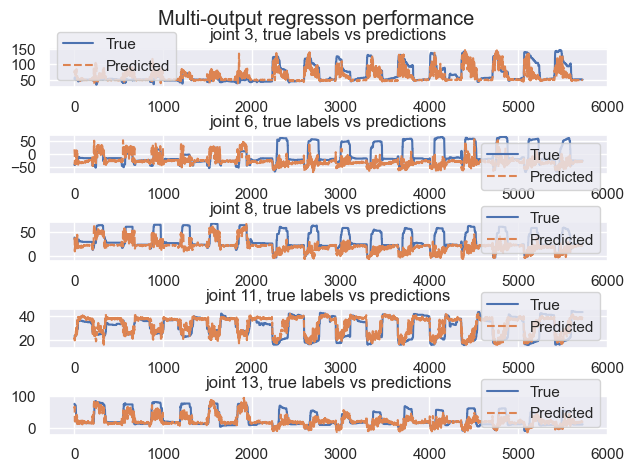

In [45]:

plt.close("all")
fig, ax = plt.subplots(5, 1)
fig.tight_layout()
fig.subplots_adjust(top= 0.9)
fig.suptitle("Multi-output regresson performance")

ax[0].plot(Labels_test_mean[:,0], label="True")
ax[0].plot(y_pred_gbr[:,0], linestyle="--", label="Predicted")
ax[0].set_title("joint 3, true labels vs predictions")
ax[0].legend()

ax[1].plot(Labels_test_mean[:,1], label="True")
ax[1].plot(y_pred_gbr[:,1], linestyle="--", label="Predicted")
ax[1].set_title("joint 6, true labels vs predictions")
ax[1].legend()

ax[2].plot(Labels_test_mean[:,2], label="True")
ax[2].plot(y_pred_gbr[:,2], linestyle="--", label="Predicted")
ax[2].set_title("joint 8, true labels vs predictions")
ax[2].legend()

ax[3].plot(Labels_test_mean[:,3], label="True")
ax[3].plot(y_pred_gbr[:,3], linestyle="--", label="Predicted")
ax[3].set_title("joint 11, true labels vs predictions")
ax[3].legend()

ax[4].plot(Labels_test_mean[:,4], label="True")
ax[4].plot(y_pred_gbr[:,4], linestyle="--", label="Predicted")
ax[4].set_title("joint 13, true labels vs predictions")
ax[4].legend()

In [122]:
#MSE_RF = mean_squared_error(Labels_test_mean, y_pred_random_forest)
#MSE_linear = mean_squared_error(Labels_test_mean, y_pred_linear)
MSE_GBR = np.sqrt(mean_squared_error(Labels_test_mean, y_pred_gbr))
MSE_thumb = np.sqrt(mean_squared_error(Labels_test_mean[:,0], y_pred_gbr[:,0]))
MSE_index = np.sqrt(mean_squared_error(Labels_test_mean[:,1], y_pred_gbr[:,1]))
MSE_middle = np.sqrt(mean_squared_error(Labels_test_mean[:,2], y_pred_gbr[:,2]))
MSE_ring = np.sqrt(mean_squared_error(Labels_test_mean[:,3], y_pred_gbr[:,3]))
MSE_pinky = np.sqrt(mean_squared_error(Labels_test_mean[:,4], y_pred_gbr[:,4]))


#print(f'MSE of Random Forest: {MSE_RF}')
#print(f'MSE of Linear Regression: {MSE_linear}')
print(f'RMSE of GBR: {MSE_GBR}')
print(f'RMSE of thumb: {MSE_thumb}')
print(f'RMSE of index: {MSE_index}')
print(f'RMSE of middle: {MSE_middle}')
print(f'RMSE of ring: {MSE_ring}')
print(f'RMSE of pinky: {MSE_pinky}')




RMSE of GBR: 21.07336669702499
RMSE of thumb: 19.608616523097258
RMSE of index: 41.96278956494034
RMSE of middle: 21.785155132185654
RMSE of ring: 4.827104538122205
RMSE of pinky: 19.097661195887568


In [57]:
from sklearn.metrics import r2_score
R2_GBR = r2_score(Labels_test_mean, y_pred_gbr)
R2_thumb = r2_score(Labels_test_mean[:,0], y_pred_gbr[:,0])
R2_index = r2_score(Labels_test_mean[:,1], y_pred_gbr[:,1])
R2_middle = r2_score(Labels_test_mean[:,2], y_pred_gbr[:,2])
R2_ring = r2_score(Labels_test_mean[:,3], y_pred_gbr[:,3])
R2_pinky = r2_score(Labels_test_mean[:,4], y_pred_gbr[:,4])

print(f'R2 of GBR: {R2_GBR}')
print(f'R2 of thumb: {R2_thumb}')
print(f'R2 of index: {R2_index}')
print(f'R2 of middle: {R2_middle}')
print(f'R2 of ring: {R2_ring}')
print(f'R2 of pinky: {R2_pinky}')


R2 of GBR: -0.08217747124685554
R2 of thumb: 0.518544637931124
R2 of index: -0.5446197409150813
R2 of middle: -0.4992734089228281
R2 of ring: 0.6945594234972075
R2 of pinky: 0.39994323260758946


In [53]:
def nrmse(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred)**2, axis=0))
    nrmse = rmse / (y_true.max(axis=0) - y_true.min(axis=0))
    return nrmse

nrmse_vals = nrmse(Labels_test_mean, y_pred_gbr)
for i, joint in enumerate(joint_indices):
    print(f"Joint {joint+1}: NRMSE = {nrmse_vals[i]:.3f}")

Joint 3: NRMSE = 0.171
Joint 6: NRMSE = 0.310
Joint 8: NRMSE = 0.303
Joint 11: NRMSE = 0.169
Joint 14: NRMSE = 0.201


# Chattie

In [55]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1️⃣ Remove highly correlated features
def remove_correlated_features(X, threshold=0.9):
    """
    Remove features with correlation higher than threshold.
    Returns X_filtered and indices of kept features.
    """
    corr_matrix = np.corrcoef(X, rowvar=False)
    n_features = corr_matrix.shape[0]
    to_keep = []
    removed = set()
    
    for i in range(n_features):
        if i in removed:
            continue
        to_keep.append(i)
        for j in range(i+1, n_features):
            if abs(corr_matrix[i,j]) > threshold:
                removed.add(j)
    
    X_filtered = X[:, to_keep]
    return X_filtered, to_keep

# Remove correlated features
X_train_filtered, kept_indices = remove_correlated_features(X_train_z, threshold=0.9)
X_test_filtered = X_test_z[:, kept_indices]

print(f"Reduced features: {X_train_z.shape[1]} -> {X_train_filtered.shape[1]}")

# 2️⃣ Tune GradientBoostingRegressor hyperparameters with GridSearchCV
gbr = GradientBoostingRegressor(random_state=42)
multi_gbr = MultiOutputRegressor(gbr)

param_grid = {
    'estimator__n_estimators': [100, 200],
    'estimator__learning_rate': [0.05, 0.1, 0.2],
    'estimator__max_depth': [3, 4, 5],
    'estimator__min_samples_split': [2, 5],
    'estimator__min_samples_leaf': [1, 2]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    multi_gbr,
    param_grid,
    cv=kf,
    scoring='r2',  # Could also try 'neg_mean_squared_error'
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_filtered, Labels_train_mean)

print("Best GBR parameters:", grid_search.best_params_)
print("Best cross-validated R² score:", grid_search.best_score_)

# 3️⃣ Evaluate on test set
best_gbr = grid_search.best_estimator_
y_pred_test = best_gbr.predict(X_test_filtered)

from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(Labels_test_mean, y_pred_test)
rmse = np.sqrt(mean_squared_error(Labels_test_mean, y_pred_test))

print(f"Test set R²: {r2:.3f}")
print(f"Test set RMSE: {rmse:.3f}")


Reduced features: 112 -> 62
Fitting 5 folds for each of 72 candidates, totalling 360 fits


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

# Predict on test set (already filtered features)
y_pred_test = best_gbr.predict(X_test_filtered)

# Plot predictions vs true labels for each finger joint
joint_indices = [2, 5, 7, 10, 13]  # Your selected joints
joint_names = ["Thumb", "Index", "Middle", "Ring", "Pinky"]

plt.close("all")
fig, ax = plt.subplots(len(joint_indices), 1, figsize=(12, 10))
fig.suptitle("GBR Predictions vs True Labels per Finger Joint", fontsize=14)
fig.subplots_adjust(hspace=0.4)

for i, joint in enumerate(joint_indices):
    ax[i].plot(Labels_test_mean[:, i], label="True", color="darkorange")
    ax[i].plot(y_pred_test[:, i], linestyle="--", label="Predicted", color="cornflowerblue")
    ax[i].set_title(f"{joint_names[i]} Joint (Joint {joint+1})")
    ax[i].set_xlabel("Window index")
    ax[i].set_ylabel("Angle")
    ax[i].legend()
    ax[i].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
